[HB, HB_pass] = 0.039998665384028326
N= 2, τ=0.0100, Eb=1.999400, Ergotropy=1.999200, erg/Eb=0.999899993346 Variance=1.1994865352e-03
[HB, HB_pass] = 0.05999499818161645
N= 3, τ=0.0100, Eb=2.998800, Ergotropy=2.998500, erg/Eb=0.999899996671 Variance=2.0989897401e-03
[HB, HB_pass] = 0.0799893336770338
N= 4, τ=0.0100, Eb=3.998000, Ergotropy=3.997600, erg/Eb=0.999899999977 Variance=3.1984132253e-03
[HB, HB_pass] = 0.09998166998401341
N= 5, τ=0.0100, Eb=4.997000, Ergotropy=4.996501, erg/Eb=0.999900003287 Variance=4.4978165425e-03
[HB, HB_pass] = 0.11997200768552255
N= 6, τ=0.0100, Eb=5.995800, Ergotropy=5.995201, erg/Eb=0.999900006596 Variance=5.9972595472e-03
[HB, HB_pass] = 0.13996034916420558
N= 7, τ=0.0100, Eb=6.994401, Ergotropy=6.993701, erg/Eb=0.999900009897 Variance=7.6968024029e-03
[HB, HB_pass] = 0.15994669008238488
N= 8, τ=0.0100, Eb=7.992801, Ergotropy=7.992002, erg/Eb=0.999900013206 Variance=9.5965040394e-03
[HB, HB_pass] = 0.17993103701288757
N= 9, τ=0.0100, Eb=8.991001, Ergo

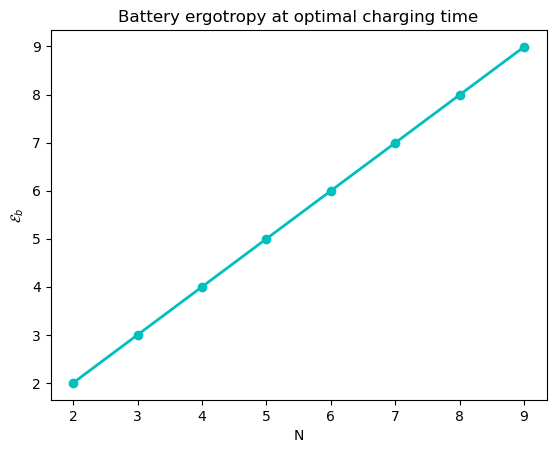

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

######################
# collective operators
######################

def collective_ops(N):
    Sp = qt.jmat(N/2, '+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2, 'z')
    HB = Sz + (N/2)*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    H = (ω * qt.tensor(a.dag()*a, qt.qeye(N+1)) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, F_ratio, FE_ratio = [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ])
    
    rho_b = res.states[-1].proj().ptrace(1)

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis

    # assign degenerate energies 
    e_vals = np.array([0] + [ω0]*N)

    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = E_B - sum(r_vals[j]*e_vals[j]for j in range(len(e_vals)))

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt( ΔE2)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    comm = HB * H_passive - H_passive * HB
    comm_norm = comm.norm()
    print("[HB, HB_pass] =", comm_norm)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f} Variance={ΔE2:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

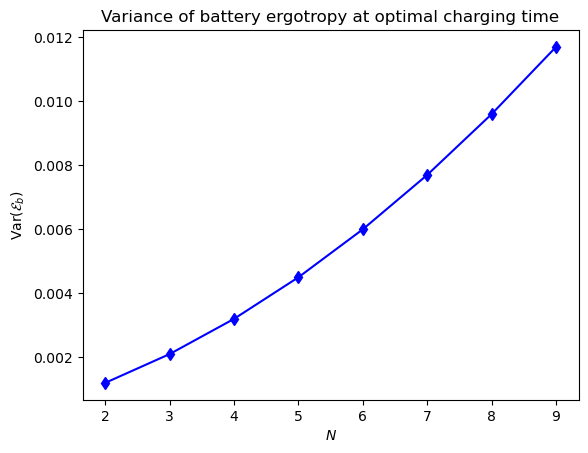

In [2]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

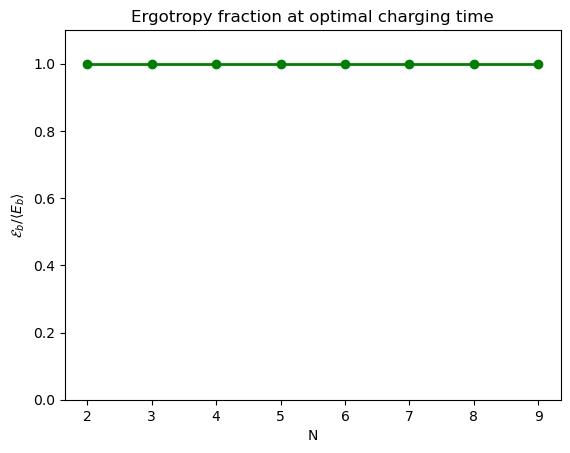

In [3]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

N= 2, τ=0.010, Relative Fluctuation =0.017323730691, Relative Fluctuation with Eb =0.017321998203
N= 3, τ=0.010, Relative Fluctuation =0.015279216082, Relative Fluctuation with Eb =0.015277688109
N= 4, τ=0.010, Relative Fluctuation =0.014147115782, Relative Fluctuation with Eb =0.014145701070
N= 5, τ=0.010, Relative Fluctuation =0.013422546737, Relative Fluctuation with Eb =0.013421204527
N= 6, τ=0.010, Relative Fluctuation =0.012917327906, Relative Fluctuation with Eb =0.012916036258
N= 7, τ=0.010, Relative Fluctuation =0.012544348109, Relative Fluctuation with Eb =0.012543093798
N= 8, τ=0.010, Relative Fluctuation =0.012257473628, Relative Fluctuation with Eb =0.012256248042
N= 9, τ=0.010, Relative Fluctuation =0.012029898457, Relative Fluctuation with Eb =0.012028695665


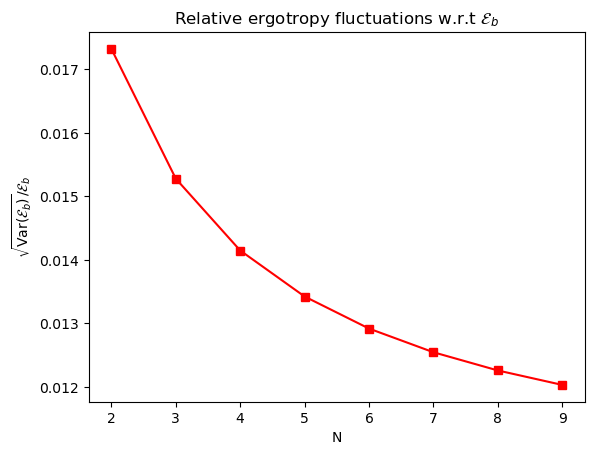

In [4]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
plt.show()

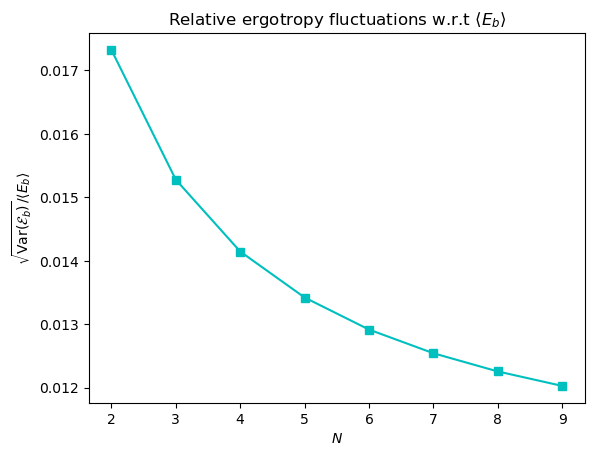

In [5]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()